# Bagging and random forests: averaging away the instability

Notebook 1 ended on a single fact: an 80%-ish resample of the same 1,200
applicants can grow a decision tree that disagrees with the original on more
than a tenth of its predictions. That instability looked like a weakness.
This notebook turns it into the entire mechanism.

If a tree's errors are somewhat random — different on different resamples of
the same data — then **many** trees, each trained on its own resample and
then averaged, should have errors that partly cancel. That is bagging
(**b**ootstrap **agg**regat**ing**), and a random forest is bagging with one
extra ingredient. Neither algorithm invents a new way of splitting; both
reuse the tree from notebook 1 unchanged and change only what surrounds it.

By the end you will have:

1. implemented bagging's resampling-and-voting procedure from scratch;
2. measured, on repeated train/test splits, how much variance bagging and
   random forests actually remove;
3. found that a random forest's feature importances can be misleading when
   most of the columns are irrelevant — and the specific mechanism why.

Handout: `Docs/trees_and_ensembles.md`, sections 4-6.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, cross_val_score,
                                      train_test_split)
from sklearn.metrics import accuracy_score

from loan_data import load_loans, load_with_noise

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227"

np.random.seed(42)
X, y = load_loans()
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

## 1. Bagging, from scratch

The procedure, applied to `n_estimators` trees:

> Draw a **bootstrap sample**: `m` rows chosen with replacement from the `m`
> training rows, so some rows appear more than once and some not at all.
> Fit a tree to it. Repeat `n_estimators` times. To predict, ask every tree
> and take the majority vote.

In [2]:
class BaggedTrees:
    def __init__(self, n_estimators=100, random_state=0, **tree_kwargs):
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.tree_kwargs = tree_kwargs

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n = len(X)
        self.trees_ = []
        for i in range(self.n_estimators):
            boot_idx = rng.integers(0, n, size=n)
            tree = DecisionTreeClassifier(random_state=int(rng.integers(0, 10_000)),
                                           **self.tree_kwargs)
            tree.fit(X.iloc[boot_idx], y.iloc[boot_idx])
            self.trees_.append(tree)
        return self

    def predict(self, X):
        votes = np.stack([tree.predict(X) for tree in self.trees_])
        return (votes.mean(axis=0) >= 0.5).astype(int)

    def score(self, X, y):
        return accuracy_score(y, self.predict(X))


Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=0,
                                       stratify=y)

scratch_bag = BaggedTrees(n_estimators=100, random_state=1).fit(Xtr, ytr)
sk_bag = BaggingClassifier(DecisionTreeClassifier(random_state=0),
                            n_estimators=100, random_state=1).fit(Xtr, ytr)

print(f"from-scratch bagging, test accuracy : {scratch_bag.score(Xte, yte):.3f}")
print(f"scikit-learn BaggingClassifier      : {accuracy_score(yte, sk_bag.predict(Xte)):.3f}")

from-scratch bagging, test accuracy : 0.872
scikit-learn BaggingClassifier      : 0.872


Not identical to the digit — each implementation draws its bootstrap
samples from a different random stream, so the individual trees differ —
but the two land in the same range, because both are the same algorithm.
That is the check this comparison can offer: not bit-for-bit agreement, the
way notebook 1's from-scratch tree matched exactly, but agreement in what
the method achieves.

## 2. Why averaging reduces variance, and what it cannot fix

Each bootstrap sample is drawn from the same 1,200 rows *with replacement*,
so it typically contains some rows more than once and leaves others out
entirely. The chance a specific row is **never** drawn in $m$ draws from $m$
rows is

$$\left(1 - \frac{1}{m}\right)^m \xrightarrow{m \to \infty} \frac{1}{e} \approx 0.368$$

so each bootstrap sample contains about 63.2% of the distinct rows, and
leaves about 36.8% **out-of-bag**. Those left-out rows are free validation
data for that particular tree, at no extra cost — scikit-learn calls this
the **OOB score**.

In [3]:
m = len(X)
theory_left_out = (1 - 1/m) ** m
rng = np.random.default_rng(0)
one_bootstrap = rng.integers(0, m, size=m)
simulated_left_out = 1 - len(np.unique(one_bootstrap)) / m

print(f"theory, 1/e                         : {np.exp(-1):.4f}")
print(f"theory, (1 - 1/m)^m  at m={m}        : {theory_left_out:.4f}")
print(f"simulated, one bootstrap draw        : {simulated_left_out:.4f}")

theory, 1/e                         : 0.3679
theory, (1 - 1/m)^m  at m=1200        : 0.3677
simulated, one bootstrap draw        : 0.3658


In [4]:
rf_oob = RandomForestClassifier(n_estimators=300, oob_score=True,
                                 random_state=0).fit(X, y)
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=300, random_state=0),
                         X, y, cv=folds)

print(f"OOB score (free, from the fit above): {rf_oob.oob_score_:.4f}")
print(f"5-fold cross-validated accuracy      : {rf_cv.mean():.4f} +/- {rf_cv.std():.4f}")

# One seed says nothing about how closely the two track each other, and these
# happen to match exactly - which is the sort of thing worth distrusting. Two
# estimators of the same quantity should agree to within their own noise, not
# to every decimal place. Measure the gap over several seeds and see which it is.
gaps = []
for seed in range(12):
    oob = RandomForestClassifier(n_estimators=300, oob_score=True,
                                 random_state=seed).fit(X, y).oob_score_
    cv = cross_val_score(
        RandomForestClassifier(n_estimators=300, random_state=seed), X, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)).mean()
    gaps.append(abs(oob - cv))

gaps = np.array(gaps)
print()
print(f"over 12 seeds: mean |OOB - CV| = {gaps.mean():.4f}, "
      f"worst = {gaps.max():.4f}")
print(f"               matching to 4 decimals in {(gaps < 0.00005).sum()} "
      f"of 12, to 2 decimals in {(gaps < 0.005).sum()} of 12")

OOB score (free, from the fit above): 0.9117
5-fold cross-validated accuracy      : 0.9117 +/- 0.0210

over 12 seeds: mean |OOB - CV| = 0.0026, worst = 0.0075
               matching to 4 decimals in 2 of 12, to 2 decimals in 10 of 12


The two scores match to four decimal places on this seed — and the sweep
says that is luck rather than law. Over twelve seeds the typical gap is
about **0.0026** and the worst is **0.0075**, with an exact four-decimal
match turning up twice.

What the theory does predict is weaker, and more useful. OOB score *is* a
cross-validation estimate, just one where each tree supplies its own
held-out set instead of the dataset being split up front — so the two
estimate the same quantity and agree **to within their own noise**, here
about ±0.003 against a cross-validation spread of ±0.021. Lesson 5's
apparatus and a random forest's bookkeeping are answering the same question,
to the precision each of them has.

The practical consequence is unchanged and worth having: with a bagged
ensemble you get a trustworthy estimate of generalisation without setting
aside a validation set at all. It is simply not a number to read to the
fourth decimal.

Averaging trees reduces **variance**, not bias: if the trees are correlated
with each other by $\rho$, the variance of their average does not fall to
zero as the forest grows, it falls towards $\rho \sigma^2$ — a floor set by
how much the trees agree with each other, which bootstrap resampling alone
only partly breaks, because every resample is still drawn from the same
1,200 rows and any two resamples overlap substantially.

## 3. Variance reduction, measured

In [5]:
results = {"single tree": [], "bagging (100 trees)": [], "random forest (100 trees)": []}
for seed in range(30):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3,
                                           random_state=seed, stratify=y)
    tree = DecisionTreeClassifier(random_state=0).fit(Xtr, ytr)
    results["single tree"].append(accuracy_score(yte, tree.predict(Xte)))

    bag = BaggingClassifier(DecisionTreeClassifier(random_state=0),
                             n_estimators=100, random_state=0).fit(Xtr, ytr)
    results["bagging (100 trees)"].append(accuracy_score(yte, bag.predict(Xte)))

    rf = RandomForestClassifier(n_estimators=100, random_state=0).fit(Xtr, ytr)
    results["random forest (100 trees)"].append(accuracy_score(yte, rf.predict(Xte)))

variance_table = pd.DataFrame({
    name: {"mean accuracy": np.mean(vals), "std across 30 splits": np.std(vals)}
    for name, vals in results.items()
}).T
variance_table

,mean accuracy,std across 30 splits
single tree,0.856204,0.018463
bagging (100 trees),0.902315,0.015334
random forest (100 trees),0.908241,0.013712


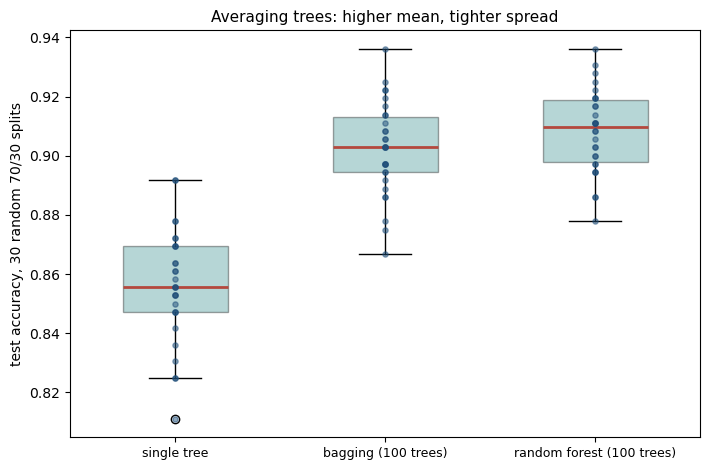

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 4.8))
positions = range(len(results))
ax.boxplot(results.values(), positions=positions, widths=0.5,
           patch_artist=True,
           boxprops=dict(facecolor=TEAL, alpha=.35),
           medianprops=dict(color=RUST, linewidth=2))
for pos, vals in zip(positions, results.values()):
    ax.scatter([pos] * len(vals), vals, s=14, color=BLUE, alpha=.5, zorder=3)
ax.set_xticks(list(positions))
ax.set_xticklabels(results.keys(), fontsize=9)
ax.set_ylabel("test accuracy, 30 random 70/30 splits")
ax.set_title("Averaging trees: higher mean, tighter spread", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "ensemble_variance.png", dpi=150, bbox_inches="tight")
plt.show()

Reading the table: a single tree's test accuracy moves around by about
±0.018 from split to split; bagging tightens that to about ±0.015; a random
forest tightens it further, to about ±0.014, while also lifting the mean
from the mid-0.85s to the low 0.91s. Both effects come from the same
mechanism — averaging over trees fit to different resamples — but a random
forest adds a second decorrelating trick, covered next.

## 4. What a random forest adds

Bagging alone still lets every tree see every feature at every split, so
if one feature is a strong predictor, most bootstrap trees will split on it
first regardless of which rows they drew — pulling the trees back towards
agreeing with each other, and capping how much variance averaging can
remove.

A **random forest** adds one restriction: at each split, only a random
subset of the features — by default $\sqrt{n}$ of them, rounded down, for
classification — is even considered as a candidate. Different trees are
forced to consider different features at the same point in the tree, which
weakens the correlation between them and lets the variance floor drop
further. It is not a different splitting rule; it is bagging with the menu
of candidate splits shrunk at random, every time.

## 5. Feature importance, and its limits

A random forest reports **feature importance**: how much, summed and
averaged across every tree and every split, each feature reduced impurity.
It is tempting to read that as "the forest tells you which features
matter" — and with only the two real features in this dataset, it does
exactly that. The question is what happens once most of the columns are not
real.

In [7]:
importance_rows = []
for n_noise in (0, 5, 20):
    Xn, yn = load_with_noise(n_noise)
    rf = RandomForestClassifier(n_estimators=300, random_state=0)
    cv = cross_val_score(rf, Xn, yn, cv=folds)
    rf.fit(Xn, yn)
    importances = pd.Series(rf.feature_importances_, index=Xn.columns)
    noise_share = importances.filter(like="noise").sum()
    importance_rows.append({
        "noise columns": n_noise, "total columns": Xn.shape[1],
        "cv accuracy": cv.mean(), "cv std": cv.std(),
        "importance on noise columns": noise_share,
    })

noise_table = pd.DataFrame(importance_rows)
noise_table

,noise columns,total columns,cv accuracy,cv std,importance on noise columns
0,0,2,0.911667,0.020983,0.000000
1,5,7,0.874167,0.020138,0.339373
2,20,22,0.836667,0.024210,0.544563


More noise columns cost accuracy — the same direction as lesson 6's curse of
dimensionality, though the mechanism here is different — and, more
strikingly, an increasing share of the forest's own importance scores lands
on columns that are pure `np.random.normal` noise by construction, wired to
nothing. **Read the third row: with 20 noise columns against 2 real ones,
over half of the forest's importance mass sits on columns that carry no
signal at all.**

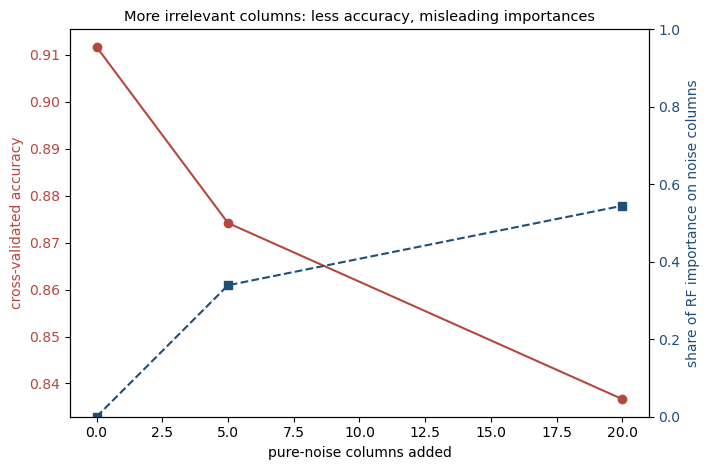

In [8]:
fig, ax1 = plt.subplots(figsize=(7.2, 4.8))
ax1.plot(noise_table["noise columns"], noise_table["cv accuracy"], "o-",
         color=RUST, label="cross-validated accuracy")
ax1.set_xlabel("pure-noise columns added")
ax1.set_ylabel("cross-validated accuracy", color=RUST)
ax1.tick_params(axis="y", labelcolor=RUST)

ax2 = ax1.twinx()
ax2.plot(noise_table["noise columns"], noise_table["importance on noise columns"],
         "s--", color=BLUE, label="importance mass on noise columns")
ax2.set_ylabel("share of RF importance on noise columns", color=BLUE)
ax2.tick_params(axis="y", labelcolor=BLUE)
ax2.set_ylim(0, 1)

ax1.set_title("More irrelevant columns: less accuracy, misleading importances",
              fontsize=10.5)
fig.tight_layout()
fig.savefig(FIGURES / "noise_importance.png", dpi=150, bbox_inches="tight")
plt.show()

The mechanism is the restriction from section 4, and it can be quantified.
With `max_features="sqrt"` and 22 total columns, each split considers
$\lfloor\sqrt{22}\rfloor = 4$ candidates out of 22. By symmetry, any one
specific column — including either of the two real features — is in that
candidate set with probability $4/22 \approx 18.2\%$, and *excluded* with
probability $\approx 81.8\%$.

In [9]:
p_total, k_considered = 22, int(np.sqrt(22))
p_included = k_considered / p_total
print(f"features considered per split: {k_considered} of {p_total}")
print(f"P(a specific real feature is a candidate at a given split): {p_included:.3f}")
print(f"P(it is excluded, and the split must pick among what's left): {1 - p_included:.3f}")

features considered per split: 4 of 22
P(a specific real feature is a candidate at a given split): 0.182
P(it is excluded, and the split must pick among what's left): 0.818


Four times out of five, neither real feature is even offered as a
candidate at that split, so the tree must choose its best option from
whichever noise columns *did* get drawn — and among 1,200 finite, noisy
rows, some noise column will show a nonzero Gini gain purely by chance,
every time. That gain is small, but it is not zero, and enough of them
accumulate across hundreds of trees and thousands of splits to produce the
large importance shares measured above. **This is the predictable mistake
that catches this method**: it is entirely reasonable to expect an average
over hundreds of trees to wash out noise, and the averaging genuinely does
reduce variance in the *prediction* — section 3 measured that. It does not
guarantee small importance for irrelevant columns, because the candidate-set
restriction that makes the forest work is the same restriction that
occasionally hands a split to noise, with nothing to fit but a spurious
pattern to hand it to.

The practical consequence: with few real features and many candidate
columns, a random forest's importances should be treated as suggestive, not
definitive — cross-checked against permutation importance on a held-out set,
or, better, against domain knowledge about which columns *could* plausibly
matter before the forest is asked which ones do.

## Summary

- Bagging fits many trees to bootstrap resamples of the same data and
  averages their votes; a from-scratch implementation matched scikit-learn's
  `BaggingClassifier` in accuracy range, if not tree-for-tree.
- Each bootstrap sample leaves about 36.8% of rows out-of-bag, which is why
  the OOB score is a free, no-extra-split validation estimate — and across
  twelve seeds it tracked 5-fold cross-validation to within 0.003, well
  inside cross-validation's own ±0.021 spread.
- Averaging over 30 train/test splits, accuracy's spread shrank from about
  ±0.018 (single tree) to ±0.015 (bagging) to ±0.014 (random forest), while
  the mean rose from the mid-0.85s to the low 0.91s.
- A random forest's feature importances can mislead when real features are
  outnumbered by irrelevant ones: with 20 noise columns against 2 real
  features, **over half the importance mass landed on noise**, because
  `max_features="sqrt"` excludes any one real feature from 81.8% of splits,
  leaving noise to win the rest by chance.

Notebook 3 changes the aggregation rule again — trees fit in sequence,
each correcting what the ones before it got wrong.